In [1]:
import numpy as np
import matplotlib.pyplot as plt
from rkhs import RKHS

In [2]:
# Generate synthetic data on the interval [0,1]
# Here we define a smooth function for demonstration purposes.
x = np.linspace(0, 1, 50)
# Example function: f(x) = sin(2πx) + 0.5*cos(3πx)
f_values = np.sin(2 * np.pi * x) + 0.5 * np.cos(3 * np.pi * x)
data_series = np.column_stack((x, f_values))
data_series[:5]

array([[0.        , 0.5       ],
       [0.02040816, 0.61865674],
       [0.04081633, 0.71711296],
       [0.06122449, 0.79431106],
       [0.08163265, 0.84989223]])

In [3]:
# Create an RKHS object with m basis functions and a specified fractal depth.
m = 5
fractal_depth = 2
rkhs_obj = RKHS(data_series=data_series, m=m, fractal_depth=fractal_depth)

Vertical scaling factors s_values were not provided, so they were initialised randomly.
Building the Basis functions for the RKHS:
	Built u_1.
	Built F_[u_1].
	Built u_2.
	Built F_[u_2].
	Built u_3.
	Built F_[u_3].
	Built u_4.
	Built F_[u_4].
	Built u_5.
	Built F_[u_5].
Established the refined x grid with 122855 points.
Built matrix A = [<F_[u_i], F_[u_j]>].
Built matrix B = inverse(A).


In [4]:
# Print out the matrix A (inner products) and its inverse B.
print("Matrix A (inner products between fractal basis functions):")
print(rkhs_obj.A)
print("\nMatrix B (inverse of A):")
print(rkhs_obj.B)

Matrix A (inner products between fractal basis functions):
[[ 1.15342775  0.00289649  0.0986651   0.00880975 -0.01577779]
 [ 0.00289649  0.51102125  0.0251952   0.00518938  0.00512469]
 [ 0.0986651   0.0251952   1.42802131  0.09301906 -0.04487409]
 [ 0.00880975  0.00518938  0.09301906  0.73683601 -0.08056361]
 [-0.01577779  0.00512469 -0.04487409 -0.08056361  0.98567755]]

Matrix B (inverse of A):
[[ 8.72263999e-01 -2.09171218e-03 -5.97727030e-02 -1.65295013e-03
   1.11169247e-02]
 [-2.09171218e-03  1.95879632e+00 -3.41064399e-02 -1.08486109e-02
  -1.26570005e-02]
 [-5.97727030e-02 -3.41064399e-02  7.11385841e-01 -8.61655240e-02
   2.45645161e-02]
 [-1.65295013e-03 -1.08486109e-02 -8.61655240e-02  1.38003507e+00
   1.08903291e-01]
 [ 1.11169247e-02 -1.26570005e-02  2.45645161e-02  1.08903291e-01
   1.02479377e+00]]


In [5]:
np.linalg.eigvals(rkhs_obj.A)

array([1.47850669, 1.12270851, 0.99885199, 0.70473789, 0.5101788 ])


Kernel function k(1, 1) = 8.396389728466772


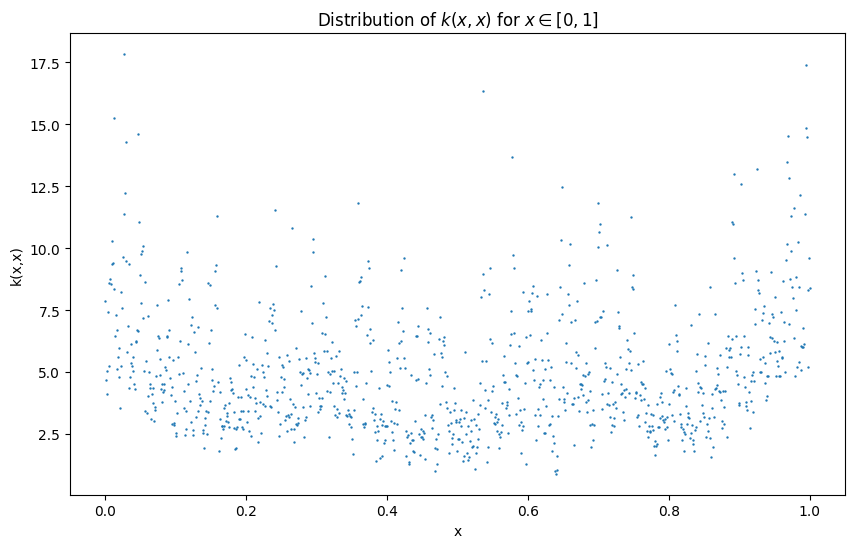

In [6]:
# Evaluate the kernel function between two sample points.
x1 = 1
x2 = 1
k_val = rkhs_obj.kernel_function(x1, x2)
print(f"\nKernel function k({x1}, {x2}) = {k_val}")
x_plot = np.linspace(0, 1, 1000)
plt.figure(figsize=(10, 6))

kf = np.array([rkhs_obj.kernel_function(x,x) for x in x_plot])
# rkhs_obj.kernel_array(x_plot, x_plot)
plt.scatter(x_plot, kf, s=0.5)
plt.title(r"Distribution of $k(x, x)$ for $x \in [0, 1]$")
plt.xlabel("x")
plt.ylabel("k(x,x)")
plt.show()

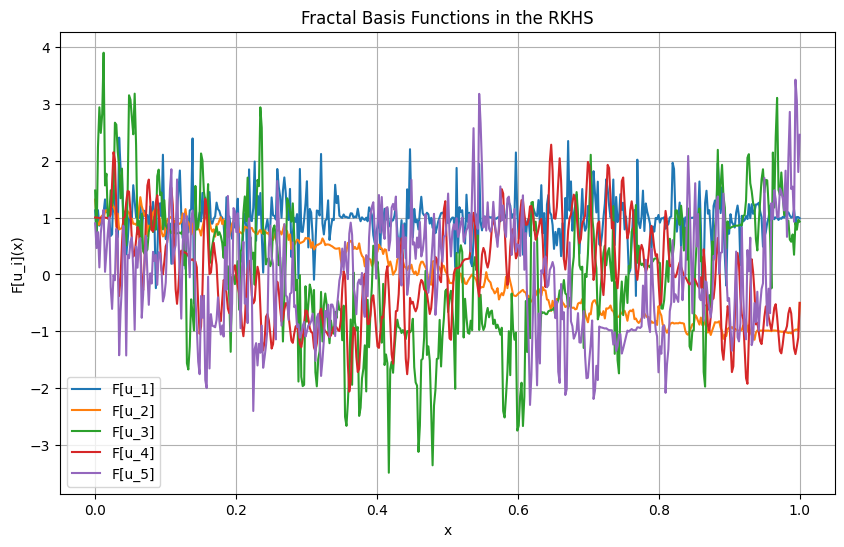

In [ ]:
# Plot the fractal basis functions over the interval [0, 1].
x_plot = np.linspace(0, 1, 500)
plt.figure(figsize=(10, 6))
for i in range(1, m+1):
    Fi = rkhs_obj.fractal_basis[f"{i}"]
    y_vals = np.array([Fi(xi) for xi in x_plot])
    plt.plot(x_plot, y_vals, label=f"F[u_{i}]")
plt.title("Fractal Basis Functions in the RKHS")
plt.xlabel("x")
plt.ylabel("F[u_i](x)")
plt.legend()
plt.grid(True)
plt.show()